# PCA and Cluster Analysis of Wine Chemical Profiles

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 20, 2026

**Analysis:**  Principal component analysis, k-means clustering, and hierarchical clustering  
**Data file:** `wine-clustering.csv` / `01-wine-clustering.csv`

## Purpose

This notebook analyzes 178 wines using 13 chemical measurements.  The analysis has four objectives:

1. Standardize the measurements and use principal component analysis (PCA) to retain the smallest set of components that explains at least 80% of total variance.
2. Apply k-means to the retained component scores and compare several values of $k$.
3. Perform hierarchical clustering and compare its structure with the k-means solution.
4. Investigate the assumptions, limitations, stability, and practical meaning of the results.

The source file contains no class or cultivar label.  Accordingly, every cluster is interpreted as a data-driven chemical profile—not as a confirmed grape cultivar, quality grade, or geographic origin.

## Scholarly context

PCA replaces correlated measurements with uncorrelated linear combinations ordered by the amount of variance they explain.  Jolliffe and Cadima (2016) emphasize that PCA can make multivariate data easier to interpret while preserving much of its information.  Their discussion also supports standardizing variables when measurement scales differ substantially, as they do here.

Clustering is exploratory:  an algorithm can produce groups even when no uniquely correct grouping exists.  Jain (2010) explains that k-means favors compact groups under Euclidean distance and that cluster selection requires attention to scaling, initialization, shape, and validation.  This notebook therefore compares $k=2$ through $k=10$, uses multiple internal validation measures, and evaluates stability instead of relying only on a visual elbow.

Wine chemistry provides a practical application of multivariate analysis because researchers frequently measure many related chemical characteristics for each wine.  Tufariello et al. (2022) describe how PCA, hierarchical clustering, and related methods can organize complex wine-chemistry measurements and reveal relationships that may not be apparent when each variable is examined separately.  Their review supports the use of these methods for exploring the combined chemical profiles in the present dataset.

## 1. Setup and reproducibility

The analysis uses a fixed random seed.  The setup cell also reports the active Python executable and package versions, which makes mixed-kernel problems easier to diagnose.

In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

plt.close("all")

import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist
from scipy.stats import chi2
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 8555
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Python executable: {sys.executable}")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

Python executable: C:\Users\perez\.conda\envs\dds8555-clustering\python.exe
Python: 3.12.13
NumPy: 2.0.2
pandas: 3.0.5
SciPy: 1.18.0
scikit-learn: 1.9.0
Matplotlib: 3.11.0


## 2. Load and verify the project data

The loader checks several common project locations, so the notebook can be run from the project root or from the folder containing the CSV.  The data are read from the project file rather than downloaded at execution time.

In [2]:
candidate_paths = [
    Path("wine-clustering.csv"),
    Path("01-wine-clustering.csv"),
    Path("upload") / "wine-clustering.csv",
    Path("upload") / "01-wine-clustering.csv",
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    searched = "\n".join(f"  - {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(
        "The wine CSV was not found. Place wine-clustering.csv or "
        "01-wine-clustering.csv beside this notebook or in an upload folder.\n"
        f"Locations searched:\n{searched}"
    )

wine = pd.read_csv(data_path)
expected_columns = [
    "Alcohol", "Malic_Acid", "Ash", "Ash_Alcanity", "Magnesium",
    "Total_Phenols", "Flavanoids", "Nonflavanoid_Phenols",
    "Proanthocyanins", "Color_Intensity", "Hue", "OD280", "Proline",
]

if list(wine.columns) != expected_columns:
    raise ValueError(
        "The file does not have the expected 13 wine-chemistry columns.\n"
        f"Found: {list(wine.columns)}"
    )
if not all(pd.api.types.is_numeric_dtype(wine[column]) for column in wine.columns):
    raise TypeError("All 13 analysis variables must be numeric.")

print(f"Loaded: {data_path.resolve()}")
print(f"Shape: {wine.shape[0]} observations × {wine.shape[1]} variables")
display(wine.head().T)

Loaded: C:\Users\perez\OneDrive\National University\PhD\04_PredictiveAnalytics\Week07\wine-clustering.csv
Shape: 178 observations × 13 variables


,0,1,2,3,4
Alcohol,14.23,13.20,13.16,14.37,13.24
Malic_Acid,1.71,1.78,2.36,1.95,2.59
Ash,2.43,2.14,2.67,2.50,2.87
Ash_Alcanity,15.60,11.20,18.60,16.80,21.00
Magnesium,127.00,100.00,101.00,113.00,118.00
Total_Phenols,2.80,2.65,2.80,3.85,2.80
Flavanoids,3.06,2.76,3.24,3.49,2.69
Nonflavanoid_Phenols,0.28,0.26,0.30,0.24,0.39
Proanthocyanins,2.29,1.28,2.81,2.18,1.82
Color_Intensity,5.64,4.38,5.68,7.80,4.32


### Dataset provenance

The project CSV exactly matches the 13-feature matrix in the UCI Wine dataset, which contains chemical analyses of wines from three cultivars grown in the same Italian region (Aeberhard & Forina, 1992).  The target labels distributed by UCI are intentionally absent from the project file and are neither reconstructed nor used in the analysis.  Excluding the cultivar labels ensures that the clustering remains entirely unsupervised.

In [3]:
quality_summary = pd.DataFrame({
    "Measure": [
        "Observations", "Numeric variables", "Missing cells",
        "Duplicate rows", "Constant variables",
    ],
    "Result": [
        len(wine), wine.shape[1], int(wine.isna().sum().sum()),
        int(wine.duplicated().sum()), int((wine.nunique() <= 1).sum()),
    ],
})

descriptive = wine.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
display(quality_summary)
display(descriptive.round(3))

,Measure,Result
0,Observations,178
1,Numeric variables,13
2,Missing cells,0
3,Duplicate rows,0
4,Constant variables,0


,mean,std,min,25%,50%,75%,max
Alcohol,13.001,0.812,11.03,12.362,13.050,13.678,14.83
Malic_Acid,2.336,1.117,0.74,1.602,1.865,3.082,5.80
Ash,2.367,0.274,1.36,2.210,2.360,2.558,3.23
Ash_Alcanity,19.495,3.340,10.60,17.200,19.500,21.500,30.00
Magnesium,99.742,14.282,70.00,88.000,98.000,107.000,162.00
Total_Phenols,2.295,0.626,0.98,1.742,2.355,2.800,3.88
Flavanoids,2.029,0.999,0.34,1.205,2.135,2.875,5.08
Nonflavanoid_Phenols,0.362,0.124,0.13,0.270,0.340,0.438,0.66
Proanthocyanins,1.591,0.572,0.41,1.250,1.555,1.950,3.58
Color_Intensity,5.058,2.318,1.28,3.220,4.690,6.200,13.00


**Data-quality interpretation.**  The file contains 178 complete and unique observations across 13 numeric variables.  No imputation, duplicate removal, or zero-variance filtering is required.  The descriptive statistics also show why raw Euclidean distance would be misleading:  `Proline` varies by hundreds of units, while variables such as `Hue` vary by fractions of a unit.  Without scaling, the largest-unit measurements would dominate both PCA and clustering.

## 3. Assumption investigation before PCA

PCA is appropriate for numeric measurements when the objective is to summarize linear correlation.  It does not require multivariate normality for descriptive dimension reduction, although extreme outliers can strongly influence means, correlations, and component directions.  The following checks examine scale, correlation, sampling adequacy, and potential outliers.

In [4]:
# Standardize with the sample standard deviation (n - 1 denominator).
X = (wine - wine.mean()) / wine.std(ddof=1)

scale_check = pd.DataFrame({
    "Original SD": wine.std(ddof=1),
    "Standardized mean": X.mean(),
    "Standardized SD": X.std(ddof=1),
})
display(scale_check.round(6))

assert np.allclose(X.mean().to_numpy(), 0.0, atol=1e-12)
assert np.allclose(X.std(ddof=1).to_numpy(), 1.0, atol=1e-12)

,Original SD,Standardized mean,Standardized SD
Alcohol,0.811827,-0.0,1.0
Malic_Acid,1.117146,0.0,1.0
Ash,0.274344,-0.0,1.0
Ash_Alcanity,3.339564,-0.0,1.0
Magnesium,14.282484,-0.0,1.0
Total_Phenols,0.625851,0.0,1.0
Flavanoids,0.998859,-0.0,1.0
Nonflavanoid_Phenols,0.124453,0.0,1.0
Proanthocyanins,0.572359,-0.0,1.0
Color_Intensity,2.318286,0.0,1.0


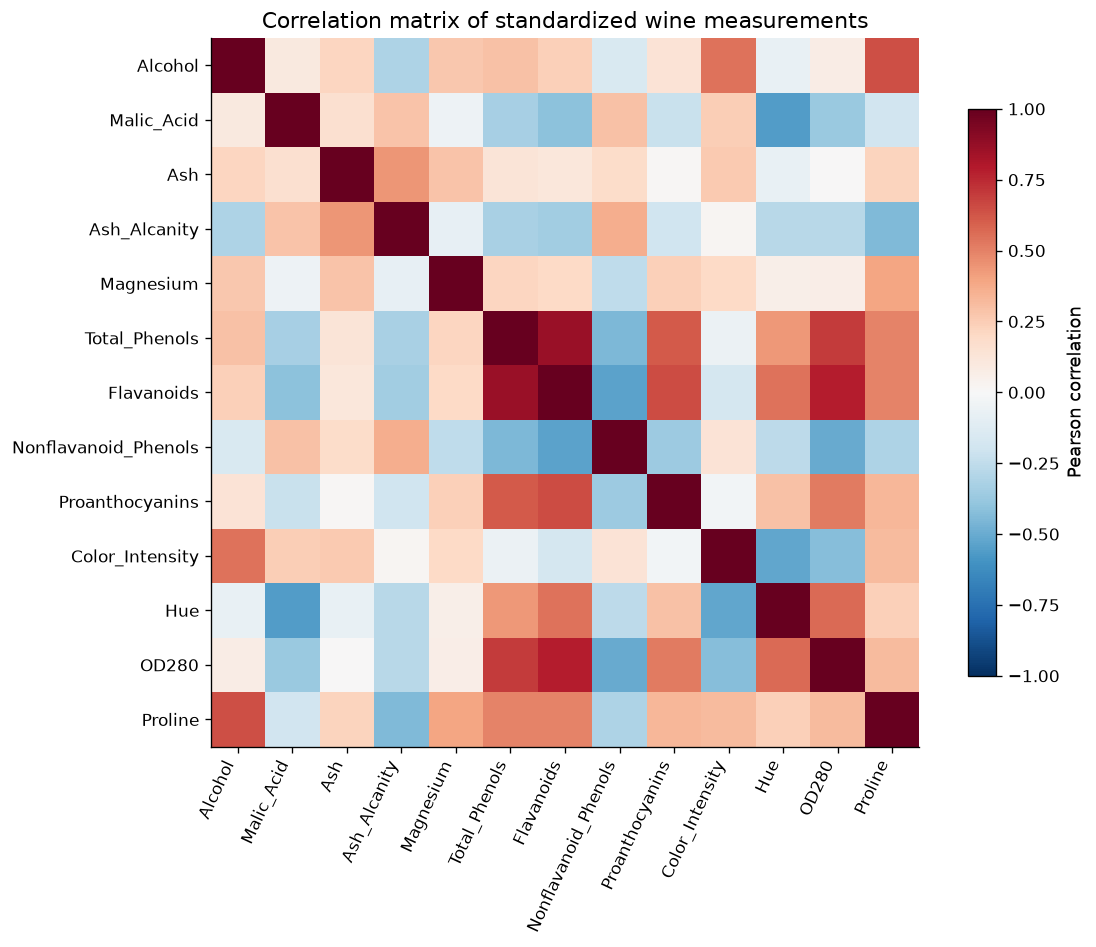

,,Correlation
Total_Phenols,Flavanoids,0.865
Flavanoids,OD280,0.787
Total_Phenols,OD280,0.700
Flavanoids,Proanthocyanins,0.653
Alcohol,Proline,0.644
Total_Phenols,Proanthocyanins,0.612
Hue,OD280,0.565
Malic_Acid,Hue,-0.561
Alcohol,Color_Intensity,0.546
Flavanoids,Hue,0.543


In [5]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=65, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)
ax.set_title("Correlation matrix of standardized wine measurements")
fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson correlation")
fig.tight_layout()
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strongest = (
    upper.stack()
    .rename("Correlation")
    .to_frame()
    .assign(Absolute=lambda frame: frame["Correlation"].abs())
    .sort_values("Absolute", ascending=False)
    .head(10)
    .drop(columns="Absolute")
)
display(strongest.round(3))

In [6]:
def bartlett_sphericity(frame):
    # Bartlett test that the correlation matrix is an identity matrix.
    n, p = frame.shape
    matrix = np.corrcoef(frame, rowvar=False)
    statistic = -(n - 1 - (2 * p + 5) / 6) * np.log(np.linalg.det(matrix))
    degrees_freedom = p * (p - 1) / 2
    p_value = chi2.sf(statistic, degrees_freedom)
    return statistic, degrees_freedom, p_value


def kmo_overall(frame):
    # Overall Kaiser-Meyer-Olkin measure from correlations and partial correlations.
    matrix = np.corrcoef(frame, rowvar=False)
    inverse = np.linalg.inv(matrix)
    partial = np.zeros_like(matrix)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[0]):
            if i != j:
                partial[i, j] = -inverse[i, j] / np.sqrt(inverse[i, i] * inverse[j, j])
    indices = np.triu_indices_from(matrix, k=1)
    squared_correlations = np.sum(matrix[indices] ** 2)
    squared_partials = np.sum(partial[indices] ** 2)
    return squared_correlations / (squared_correlations + squared_partials)


q1, q3 = wine.quantile(0.25), wine.quantile(0.75)
iqr = q3 - q1
outlier_mask = (wine < q1 - 1.5 * iqr) | (wine > q3 + 1.5 * iqr)

bartlett_stat, bartlett_df, bartlett_p = bartlett_sphericity(X)
assumption_results = pd.DataFrame({
    "Diagnostic": [
        "Bartlett chi-square", "Bartlett degrees of freedom", "Bartlett p-value",
        "Overall KMO", "IQR-flagged cells", "Rows with at least one IQR flag",
    ],
    "Result": [
        bartlett_stat, bartlett_df, bartlett_p, kmo_overall(X),
        int(outlier_mask.sum().sum()), int(outlier_mask.any(axis=1).sum()),
    ],
})
display(assumption_results)
display(
    outlier_mask.sum()
    .rename("IQR-flagged values")
    .sort_values(ascending=False)
    .to_frame()
)

,Diagnostic,Result
0,Bartlett chi-square,1.317181e+03
1,Bartlett degrees of freedom,7.800000e+01
2,Bartlett p-value,2.468617e-224
3,Overall KMO,7.786821e-01
4,IQR-flagged cells,2.100000e+01
5,Rows with at least one IQR flag,1.700000e+01


,IQR-flagged values
Magnesium,4
Ash_Alcanity,4
Color_Intensity,4
Malic_Acid,3
Ash,3
Proanthocyanins,2
Hue,1
Alcohol,0
Total_Phenols,0
Nonflavanoid_Phenols,0


**Assumption findings.**  Several measurements are strongly correlated; for example, `Total_Phenols` and `Flavanoids` have a correlation of approximately 0.865.  Bartlett's test strongly rejects an identity correlation matrix, and the overall Kaiser–Meyer–Olkin measure is approximately 0.779.  These results indicate enough shared linear structure for PCA to provide meaningful compression.  The IQR rule flags 21 cells across 17 rows.  These flags identify observations worth monitoring, but they are not proof of error.  Because the flagged values are not known errors, all observations are retained in the primary analysis. Their influence is evaluated later through a winsorization sensitivity analysis.

Independence cannot be proven from the measurement matrix.  The analysis assumes that each row represents a separately sampled wine.  The source description does not provide enough sampling detail to test whether production batches or other dependencies are present.

## 4. Principal component analysis

PCA is fitted to all 13 standardized variables.  The retention rule is specified in advance:  select the smallest number of components whose cumulative explained variance is at least 80%.

,Component,Explained variance (%),Cumulative variance (%)
0,1,36.20,36.20
1,2,19.21,55.41
2,3,11.12,66.53
3,4,7.07,73.60
4,5,6.56,80.16
5,6,4.94,85.10
6,7,4.24,89.34
7,8,2.68,92.02
8,9,2.22,94.24
9,10,1.93,96.17


Retention result: 5 components explain 80.16% of total standardized variance.


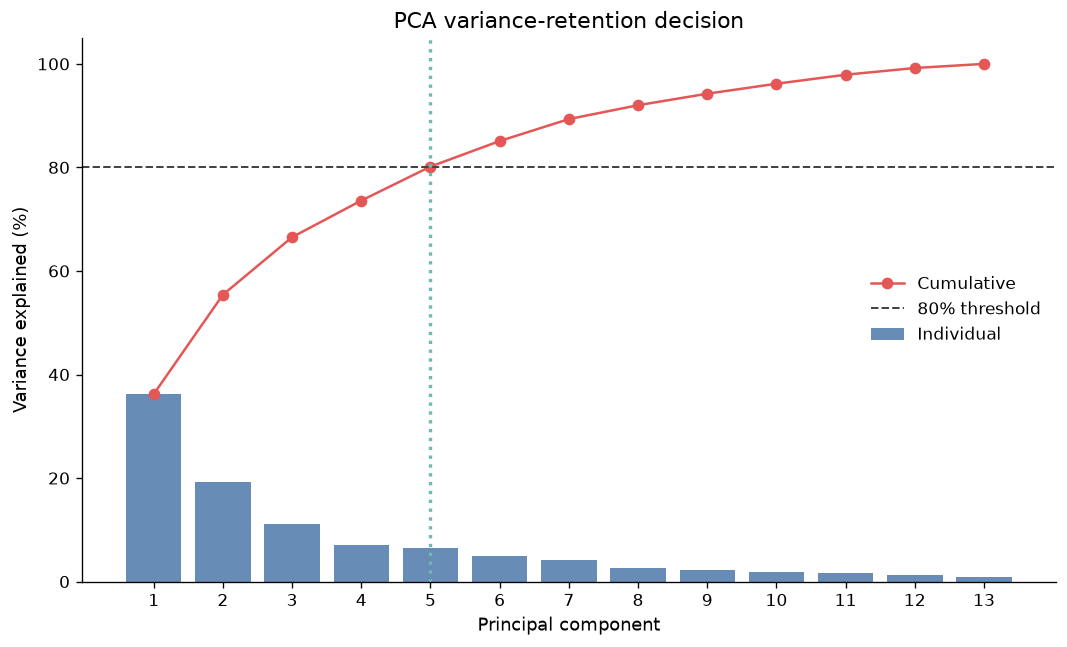

In [7]:
pca_full = PCA(svd_solver="full")
all_scores = pca_full.fit_transform(X)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_components_80 = int(np.searchsorted(cumulative, 0.80) + 1)

pca_summary = pd.DataFrame({
    "Component": np.arange(1, len(explained) + 1),
    "Explained variance": explained,
    "Cumulative variance": cumulative,
})
display(
    pca_summary.assign(
        **{
            "Explained variance (%)": pca_summary["Explained variance"] * 100,
            "Cumulative variance (%)": pca_summary["Cumulative variance"] * 100,
        }
    )
    .drop(columns=["Explained variance", "Cumulative variance"])
    .round(2)
)

print(
    f"Retention result: {n_components_80} components explain "
    f"{cumulative[n_components_80 - 1]:.2%} of total standardized variance."
)

fig, ax = plt.subplots()
components = np.arange(1, len(explained) + 1)
ax.bar(components, explained * 100, color="#4C78A8", alpha=0.85, label="Individual")
ax.plot(components, cumulative * 100, color="#E45756", marker="o", label="Cumulative")
ax.axhline(80, color="#444444", linestyle="--", linewidth=1.2, label="80% threshold")
ax.axvline(n_components_80, color="#72B7B2", linestyle=":", linewidth=2)
ax.set_xticks(components)
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
ax.set_title("PCA variance-retention decision")
ax.legend(frameon=False, loc="center right")
fig.tight_layout()
plt.show()

**PCA result.**  Five components are required to cross the 80% threshold, retaining 80.16% of total standardized variance.  The first two components explain 55.41%, so a two-dimensional plot is useful for orientation but does not fully represent the five-dimensional space used for clustering.  The remaining 19.84% is deliberately omitted to reduce dimensionality and noise; that loss of information is a limitation of the 80% rule rather than evidence that the discarded components contain no useful structure.

In [8]:
retained_scores = all_scores[:, :n_components_80]
score_columns = [f"PC{i}" for i in range(1, n_components_80 + 1)]
scores = pd.DataFrame(retained_scores, columns=score_columns, index=wine.index)

# Correlations between original standardized variables and component scores.
loadings = pca_full.components_.T * np.sqrt(pca_full.explained_variance_)
loading_table = pd.DataFrame(
    loadings[:, :n_components_80],
    index=wine.columns,
    columns=score_columns,
)
display(loading_table.round(3))

top_loadings = []
for component in score_columns:
    ranked = loading_table[component].sort_values(key=np.abs, ascending=False).head(5)
    for variable, value in ranked.items():
        top_loadings.append({"Component": component, "Variable": variable, "Loading": value})
display(pd.DataFrame(top_loadings).round(3))

,PC1,PC2,PC3,PC4,PC5
Alcohol,0.313,0.764,-0.249,-0.017,-0.245
Malic_Acid,-0.532,0.355,0.107,0.515,0.033
Ash,-0.004,0.499,0.753,-0.205,-0.132
Ash_Alcanity,-0.519,-0.017,0.736,0.058,0.061
Magnesium,0.308,0.473,0.157,-0.337,0.672
Total_Phenols,0.856,0.103,0.176,0.190,-0.138
Flavanoids,0.917,-0.005,0.181,0.146,-0.101
Nonflavanoid_Phenols,-0.648,0.045,0.205,-0.195,-0.463
Proanthocyanins,0.680,0.062,0.180,0.383,0.126
Color_Intensity,-0.192,0.837,-0.165,0.063,-0.071


,Component,Variable,Loading
0,PC1,Flavanoids,0.917
1,PC1,Total_Phenols,0.856
2,PC1,OD280,0.816
3,PC1,Proanthocyanins,0.680
4,PC1,Nonflavanoid_Phenols,-0.648
5,PC2,Color_Intensity,0.837
6,PC2,Alcohol,0.764
7,PC2,Proline,0.577
8,PC2,Ash,0.499
9,PC2,Magnesium,0.473


### Component interpretation

- **PC1**  is primarily a phenolic-composition axis.  It is strongly positive for `Flavanoids`, `Total_Phenols`, `OD280`, and `Proanthocyanins`, and negative for `Nonflavanoid_Phenols`.
- **PC2**  contrasts higher `Color_Intensity`, `Alcohol`, and `Proline` with lower `Hue`.
- **PC3**  is dominated by `Ash` and `Ash_Alcanity`.
- **PC4**  is influenced most strongly by `Malic_Acid`, with additional contributions from `Hue`, `Proanthocyanins`, and `Magnesium`.
- **PC5**  is driven primarily by `Magnesium` and, in the opposite direction, `Nonflavanoid_Phenols`.

The sign of a principal component is arbitrary; reversing every sign would describe the same axis.  Interpretation therefore depends on relative direction and magnitude, not whether a loading is labeled positive or negative in this particular run.

## Cluster-tendency assessment

,Diagnostic,Result
0,Repetitions,200.0000
1,Observations per repetition,18.0000
2,Mean Hopkins statistic,0.7235
3,Standard deviation,0.0263
4,5th percentile,0.6815
5,Median,0.7252
6,95th percentile,0.7611


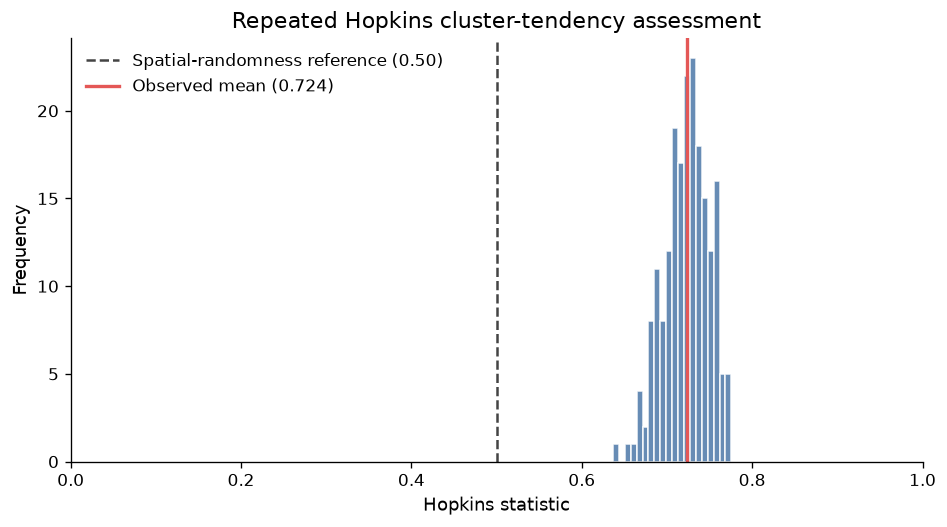

In [9]:
from sklearn.neighbors import NearestNeighbors


def hopkins_statistic(values, sample_size, rng):
    """
    Compute the Hopkins statistic.

    Values near 0.5 are consistent with spatial randomness.
    Values approaching 1 indicate increasing cluster tendency.
    """
    values = np.asarray(values)
    n_observations, n_variables = values.shape

    if not 1 < sample_size < n_observations:
        raise ValueError(
            "sample_size must be greater than 1 and "
            "smaller than the number of observations."
        )

    neighbors = NearestNeighbors(n_neighbors=2)
    neighbors.fit(values)

    # Sample observed points without replacement.
    observed_indices = rng.choice(
        n_observations,
        size=sample_size,
        replace=False,
    )
    observed_points = values[observed_indices]

    # Distance from each sampled observation to its nearest
    # other observed point. Column 0 is the point itself.
    observed_distances = neighbors.kneighbors(
        observed_points,
        n_neighbors=2,
        return_distance=True,
    )[0][:, 1]

    # Generate reference points uniformly inside the observed
    # bounding box of the retained PCA space.
    lower_bounds = values.min(axis=0)
    upper_bounds = values.max(axis=0)

    reference_points = rng.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(sample_size, n_variables),
    )

    # Distance from each reference point to the nearest
    # observed point.
    reference_distances = neighbors.kneighbors(
        reference_points,
        n_neighbors=1,
        return_distance=True,
    )[0][:, 0]

    return (
        reference_distances.sum()
        / (
            reference_distances.sum()
            + observed_distances.sum()
        )
    )


HOPKINS_REPETITIONS = 200
HOPKINS_SAMPLE_SIZE = max(
    10,
    round(0.10 * len(retained_scores)),
)

hopkins_rng = np.random.default_rng(RANDOM_STATE)

hopkins_values = np.array([
    hopkins_statistic(
        retained_scores,
        sample_size=HOPKINS_SAMPLE_SIZE,
        rng=hopkins_rng,
    )
    for _ in range(HOPKINS_REPETITIONS)
])

hopkins_summary = pd.DataFrame({
    "Diagnostic": [
        "Repetitions",
        "Observations per repetition",
        "Mean Hopkins statistic",
        "Standard deviation",
        "5th percentile",
        "Median",
        "95th percentile",
    ],
    "Result": [
        HOPKINS_REPETITIONS,
        HOPKINS_SAMPLE_SIZE,
        hopkins_values.mean(),
        hopkins_values.std(ddof=1),
        np.quantile(hopkins_values, 0.05),
        np.median(hopkins_values),
        np.quantile(hopkins_values, 0.95),
    ],
})

display(hopkins_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(
    hopkins_values,
    bins=20,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.85,
)
ax.axvline(
    0.50,
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    label="Spatial-randomness reference (0.50)",
)
ax.axvline(
    hopkins_values.mean(),
    color="#E45756",
    linewidth=2,
    label=f"Observed mean ({hopkins_values.mean():.3f})",
)
ax.set_xlim(0, 1)
ax.set_xlabel("Hopkins statistic")
ax.set_ylabel("Frequency")
ax.set_title(
    "Repeated Hopkins cluster-tendency assessment"
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Cluster tendency was evaluated using the Hopkins statistic (Hopkins & Skellam, 1954), which compares nearest-neighbor distances for randomly generated reference points with those for observations sampled from the data.  Cluster tendency was evaluated in the five-dimensional retained PCA space using 200 repeated Hopkins calculations, with approximately 10% of observations sampled during each repetition. The mean Hopkins statistic was 0.7235, with a 5th-to-95th-percentile interval of 0.6815 to 0.7611.  Because the distribution was above the spatial-randomness reference of 0.50, the retained PCA representation shows meaningful evidence of nonrandom clustering tendency. This result supports applying clustering algorithms to the data but does not prove that one uniquely correct partition exists, because Hopkins results can also reflect nonuniform geometry and depend on the chosen reference region.

## 5. K-means clustering on the retained PCA scores

K-means is applied in the five-component space rather than to the original correlated measurements.  Fifty initial centroid configurations are evaluated for each $k$ to reduce sensitivity to an unfavorable random start.  The comparison uses:

- **Inertia:**  within-cluster sum of squares; lower values are better, but inertia always declines as $k$ increases.
- **Silhouette coefficient:**  separation relative to within-cluster cohesion; higher values are better.
- **Calinski–Harabasz index:**  between-cluster separation relative to within-cluster dispersion; higher values are better.
- **Davies–Bouldin index:**  similarity between each cluster and its closest rival; lower values are better.

No single index proves that a clustering is correct, so the indices are interpreted together, consistent with Jain's (2010) treatment of clustering as an exploratory model-selection problem.

,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Smallest cluster,Largest cluster
k,,,,,,
2,1194.3777,0.3237,95.8052,1.2777,88,90
3,820.3859,0.3691,109.2327,1.0933,51,65
4,719.8687,0.3256,90.6146,1.4194,33,52
5,651.3733,0.3148,79.2237,1.3072,23,53
6,594.2178,0.3239,72.3824,1.1710,6,54
7,552.4495,0.2233,66.6566,1.4484,14,37
8,508.1756,0.2302,63.8646,1.3438,4,36
9,471.7386,0.2213,61.4754,1.3449,5,34
10,437.8279,0.2341,59.9745,1.2341,3,36


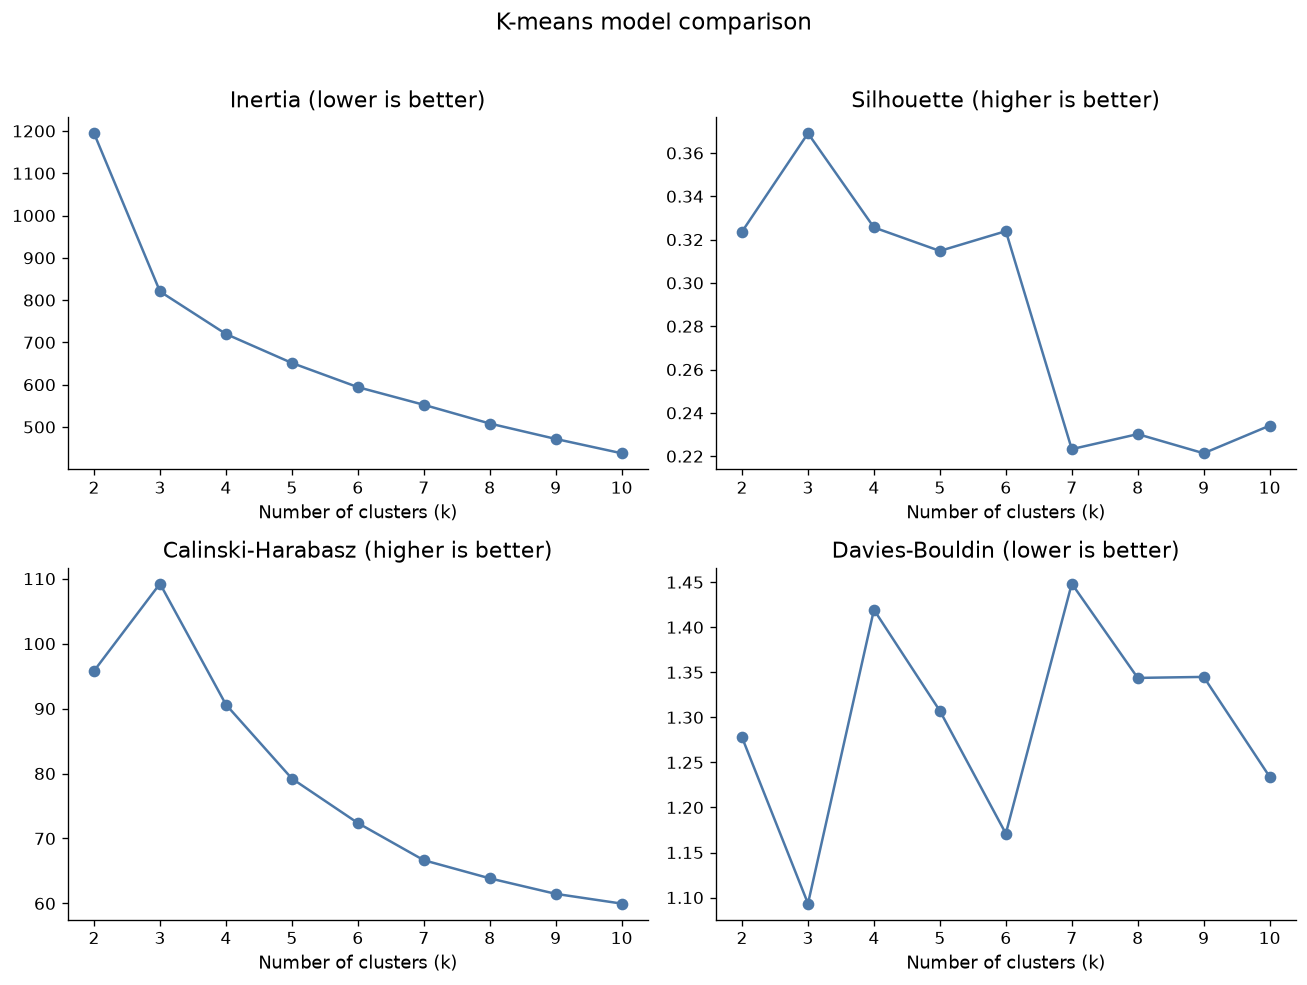

In [10]:
def clustering_metrics(values, labels, inertia=np.nan):
    return {
        "Inertia": inertia,
        "Silhouette": silhouette_score(values, labels),
        "Calinski-Harabasz": calinski_harabasz_score(values, labels),
        "Davies-Bouldin": davies_bouldin_score(values, labels),
        "Smallest cluster": int(np.bincount(labels).min()),
        "Largest cluster": int(np.bincount(labels).max()),
    }


k_values = range(2, 11)
kmeans_models = {}
kmeans_rows = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels = model.fit_predict(retained_scores)
    kmeans_models[k] = model
    kmeans_rows.append({
        "k": k,
        **clustering_metrics(retained_scores, labels, model.inertia_),
    })

kmeans_results = pd.DataFrame(kmeans_rows).set_index("k")
display(kmeans_results.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plots = [
    ("Inertia", "lower", axes[0, 0]),
    ("Silhouette", "higher", axes[0, 1]),
    ("Calinski-Harabasz", "higher", axes[1, 0]),
    ("Davies-Bouldin", "lower", axes[1, 1]),
]
for metric, direction, ax in plots:
    ax.plot(kmeans_results.index, kmeans_results[metric], marker="o", color="#4C78A8")
    ax.set_title(f"{metric} ({direction} is better)")
    ax.set_xlabel("Number of clusters (k)")
    ax.set_xticks(list(k_values))
fig.suptitle("K-means model comparison", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

,Mean subsample ARI,SD,5th percentile,Median,95th percentile
k,,,,,
2,0.7012,0.1882,0.4915,0.5974,0.9732
3,0.9572,0.0355,0.8928,0.9556,1.0000
4,0.8532,0.1224,0.6757,0.8866,1.0000
5,0.8234,0.0807,0.7200,0.8083,0.9587
6,0.7936,0.0819,0.6600,0.8016,0.9271
7,0.6527,0.1013,0.5144,0.6362,0.8125
8,0.6823,0.0969,0.5164,0.6829,0.8329
9,0.6419,0.0853,0.5072,0.6357,0.7955
10,0.6831,0.0967,0.5482,0.6751,0.8664


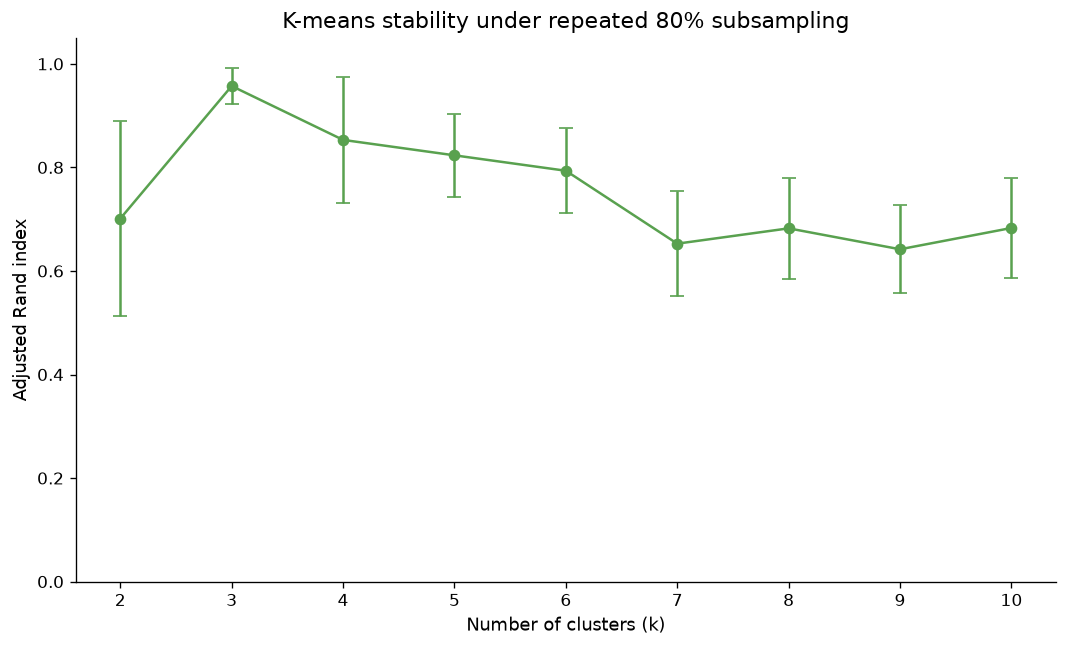

In [11]:
# Stability: refit each candidate k on 100 random 80% subsamples and compare
# the subsample labels with the full-data solution on the same observations.
rng = np.random.default_rng(RANDOM_STATE)
stability_rows = []
for k in k_values:
    full_labels = kmeans_models[k].labels_
    ari_values = []
    for repetition in range(100):
        indices = np.sort(rng.choice(len(retained_scores), size=round(0.80 * len(retained_scores)), replace=False))
        subsample_model = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=RANDOM_STATE + repetition + 1,
        )
        subsample_labels = subsample_model.fit_predict(retained_scores[indices])
        ari_values.append(adjusted_rand_score(full_labels[indices], subsample_labels))
    stability_rows.append({
        "k": k,
        "Mean subsample ARI": np.mean(ari_values),
        "SD": np.std(ari_values, ddof=1),
        "5th percentile": np.quantile(ari_values, 0.05),
        "Median": np.median(ari_values),
        "95th percentile": np.quantile(ari_values, 0.95),
    })

stability = pd.DataFrame(stability_rows).set_index("k")
display(stability.round(4))

fig, ax = plt.subplots()
ax.errorbar(
    stability.index,
    stability["Mean subsample ARI"],
    yerr=stability["SD"],
    marker="o",
    capsize=4,
    color="#59A14F",
)
ax.set_ylim(0, 1.05)
ax.set_xticks(list(k_values))
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Adjusted Rand index")
ax.set_title("K-means stability under repeated 80% subsampling")
fig.tight_layout()
plt.show()

### Selection of $k$

The evidence supports **$k=3$**.  It has the highest silhouette coefficient (0.369), the highest Calinski–Harabasz index (109.233), and the lowest Davies–Bouldin index (1.093) among the evaluated candidates.  It also has the strongest subsampling stability, with a mean adjusted Rand index of approximately 0.957.  Inertia continues to decline beyond three clusters—as it must—but the incremental reduction does not outweigh the deterioration in the other indices.

The silhouette value indicates meaningful but not perfect separation.  The groups overlap in the retained PCA space, so the three-cluster solution should be described as a useful summary of chemical structure rather than a set of naturally isolated categories.

In [12]:
selected_k = 3
kmeans_final = kmeans_models[selected_k]
kmeans_labels = kmeans_final.labels_

# Re-label clusters in a stable display order from low to high PC1 centroid.
order = np.argsort(kmeans_final.cluster_centers_[:, 0])
display_map = {old_label: new_label + 1 for new_label, old_label in enumerate(order)}
kmeans_cluster = pd.Series(
    [display_map[label] for label in kmeans_labels],
    index=wine.index,
    name="K-means cluster",
)

cluster_sizes = kmeans_cluster.value_counts().sort_index().rename("Count").to_frame()
cluster_sizes["Percent"] = cluster_sizes["Count"] / len(wine)
cluster_means = wine.assign(Cluster=kmeans_cluster).groupby("Cluster").mean()
cluster_z_means = X.assign(Cluster=kmeans_cluster).groupby("Cluster").mean()

display(
    cluster_sizes.assign(**{"Percent (%)": cluster_sizes["Percent"] * 100})
    .drop(columns="Percent")
    .round({"Percent (%)": 1})
)
display(cluster_means.T.round(3))
display(cluster_z_means.T.round(2))

,Count,Percent (%)
K-means cluster,,
1,51,28.7
2,65,36.5
3,62,34.8


Cluster,1,2,3
Alcohol,13.134,12.251,13.677
Malic_Acid,3.307,1.897,1.998
Ash,2.418,2.231,2.466
Ash_Alcanity,21.241,20.063,17.463
Magnesium,98.667,92.738,107.968
Total_Phenols,1.684,2.248,2.848
Flavanoids,0.819,2.050,3.003
Nonflavanoid_Phenols,0.452,0.358,0.292
Proanthocyanins,1.146,1.624,1.922
Color_Intensity,7.235,2.973,5.454


Cluster,1,2,3
Alcohol,0.16,-0.92,0.83
Malic_Acid,0.87,-0.39,-0.30
Ash,0.19,-0.49,0.36
Ash_Alcanity,0.52,0.17,-0.61
Magnesium,-0.08,-0.49,0.58
Total_Phenols,-0.98,-0.08,0.88
Flavanoids,-1.21,0.02,0.98
Nonflavanoid_Phenols,0.72,-0.03,-0.56
Proanthocyanins,-0.78,0.06,0.58
Color_Intensity,0.94,-0.90,0.17


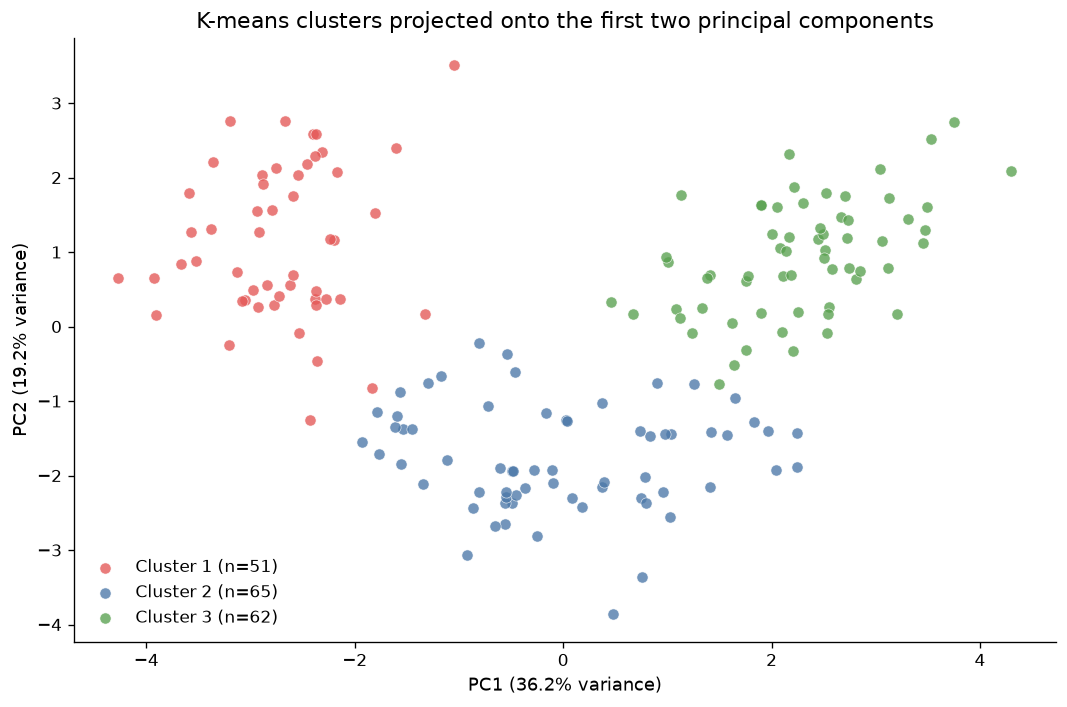

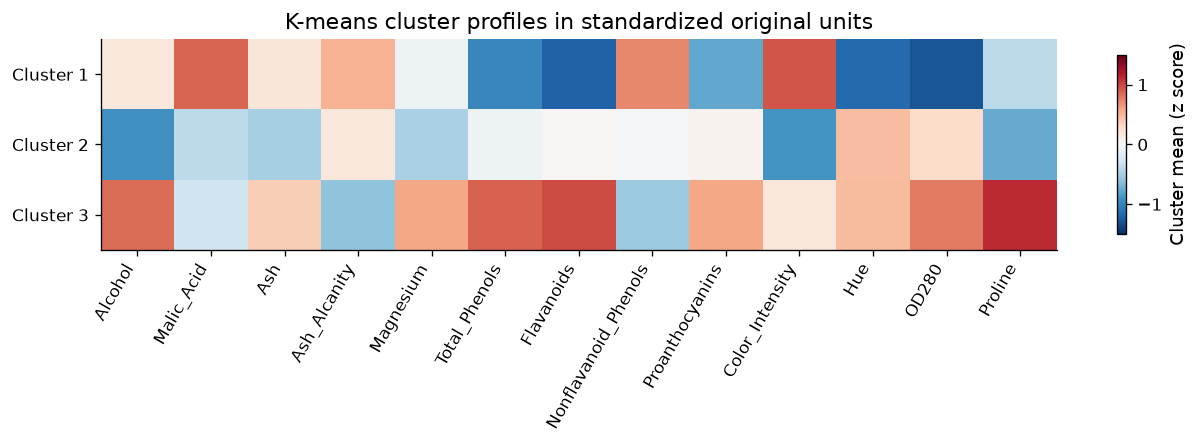

In [13]:
colors = {1: "#E45756", 2: "#4C78A8", 3: "#59A14F"}
fig, ax = plt.subplots(figsize=(9, 6))
for cluster in sorted(kmeans_cluster.unique()):
    mask = kmeans_cluster.to_numpy() == cluster
    ax.scatter(
        scores.loc[mask, "PC1"],
        scores.loc[mask, "PC2"],
        s=45,
        alpha=0.78,
        label=f"Cluster {cluster} (n={mask.sum()})",
        color=colors[cluster],
        edgecolor="white",
        linewidth=0.4,
    )
ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
ax.set_title("K-means clusters projected onto the first two principal components")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.8))
heat = ax.imshow(cluster_z_means, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax.set_xticks(range(len(cluster_z_means.columns)), cluster_z_means.columns, rotation=60, ha="right")
ax.set_yticks(range(len(cluster_z_means.index)), [f"Cluster {i}" for i in cluster_z_means.index])
ax.set_title("K-means cluster profiles in standardized original units")
fig.colorbar(heat, ax=ax, shrink=0.85, label="Cluster mean (z score)")
fig.tight_layout()
plt.show()

### Interpretation of the k-means clusters

The cluster numbers are identifiers only; they are not rankings.

- **Cluster 1 (51 wines)**  has higher `Malic_Acid`, `Color_Intensity`, and `Nonflavanoid_Phenols`, together with lower `Total_Phenols`, `Flavanoids`, `Proanthocyanins`, `Hue`, and `OD280`.  This group is distinguished most clearly by lower phenolic indicators and stronger color intensity.
- **Cluster 2 (65 wines)**  has lower `Alcohol`, `Color_Intensity`, `Proline`, and `Magnesium`, while most phenolic measures are near the overall average.  This group represents a comparatively lighter chemical profile on the alcohol/color/proline dimension.
- **Cluster 3 (62 wines)**  has higher `Alcohol`, `Magnesium`, `Total_Phenols`, `Flavanoids`, `Proanthocyanins`, `OD280`, and `Proline`, with lower `Ash_Alcanity` and `Nonflavanoid_Phenols`.  This group has the strongest positive phenolic and proline profile.

These descriptions summarize average chemical differences.  They do not establish wine quality, consumer preference, cultivar, or geographic origin because those outcomes are not present in the project data.

## 6. Hierarchical clustering

Agglomerative hierarchical clustering begins with each wine as its own group and repeatedly combines groups.  Ward linkage is used because it merges the pair that produces the smallest increase in within-cluster sum of squares.  This choice matches the compact, variance-focused geometry of k-means and requires Euclidean distance.  The analysis is performed on the same five retained PCA scores.

The dendrogram displays the complete sequence of merges.  Cutting the tree into three groups makes the hierarchical result directly comparable with the selected k-means solution.

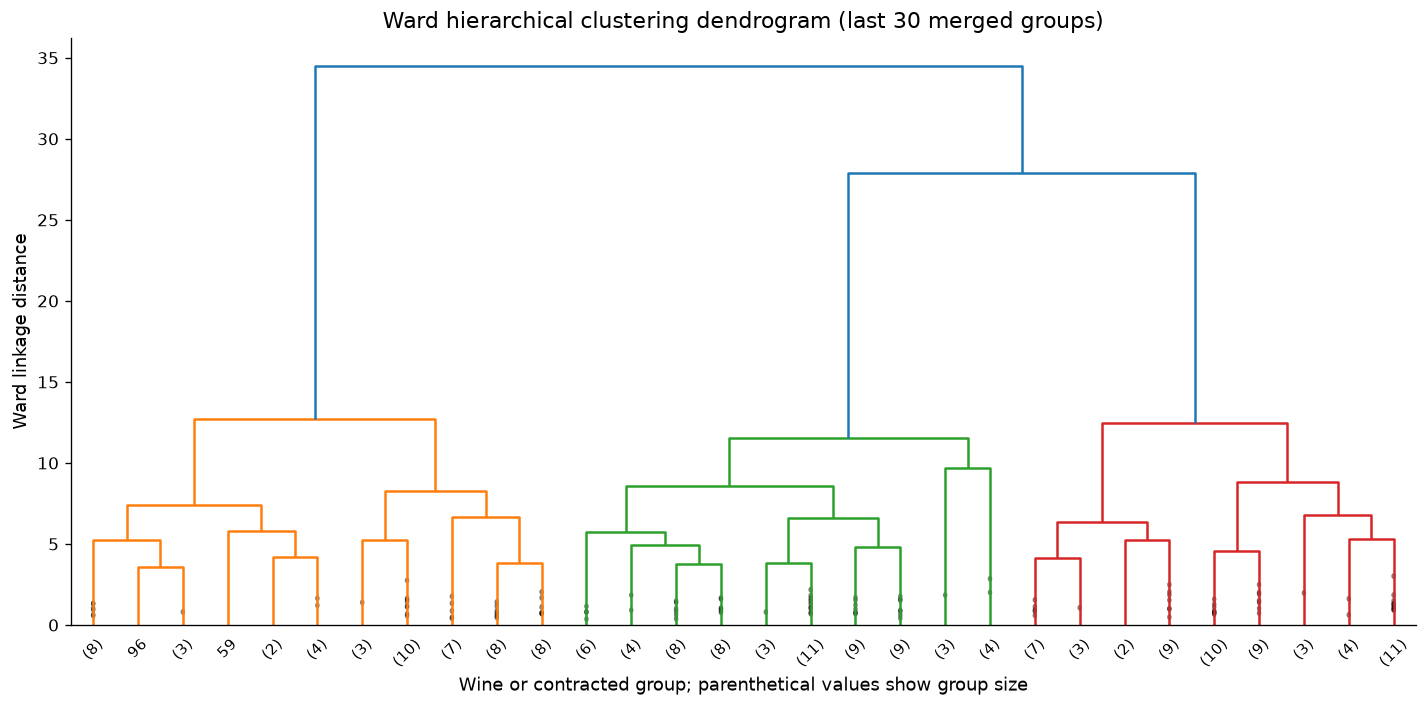

In [14]:
linkage_matrix = linkage(retained_scores, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    show_contracted=True,
    leaf_rotation=45,
    leaf_font_size=9,
    color_threshold=None,
    ax=ax,
)
ax.set_title("Ward hierarchical clustering dendrogram (last 30 merged groups)")
ax.set_xlabel("Wine or contracted group; parenthetical values show group size")
ax.set_ylabel("Ward linkage distance")
fig.tight_layout()
plt.show()

In [15]:
hierarchical_rows = []
hierarchical_labels = {}
for k in k_values:
    labels = fcluster(linkage_matrix, t=k, criterion="maxclust")
    hierarchical_labels[k] = labels
    zero_based = labels - 1
    hierarchical_rows.append({
        "k": k,
        **clustering_metrics(retained_scores, zero_based),
    })

hierarchical_results = pd.DataFrame(hierarchical_rows).set_index("k").drop(columns="Inertia")
cophenetic_correlation, _ = cophenet(linkage_matrix, pdist(retained_scores))
display(hierarchical_results.round(4))
print(f"Ward cophenetic correlation: {cophenetic_correlation:.3f}")

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Smallest cluster,Largest cluster
k,,,,,
2,0.3233,83.8147,1.1977,55,123
3,0.3468,100.0205,1.1049,55,65
4,0.2913,79.2229,1.3145,19,65
5,0.2679,70.3671,1.3527,19,65
6,0.2812,65.4199,1.4040,7,58
7,0.2859,60.7953,1.1681,3,58
8,0.2721,57.2076,1.2008,3,58
9,0.2105,54.8805,1.3463,3,36
10,0.1972,53.2594,1.3478,3,32


Ward cophenetic correlation: 0.691


## Ward Hierarchical-Clustering Stability Under Subsampling

,Mean subsample ARI,SD,5th percentile,Median,95th percentile
k,,,,,
2,0.6743,0.3191,0.0609,0.7833,0.9712
3,0.7911,0.0935,0.6531,0.7925,0.9399
4,0.7038,0.0878,0.5709,0.6944,0.8385
5,0.7185,0.0917,0.5427,0.7278,0.8429
6,0.7686,0.1072,0.5853,0.7802,0.9394
7,0.7484,0.1182,0.5586,0.7696,0.9419
8,0.6879,0.1196,0.5237,0.6824,0.8958
9,0.6606,0.0980,0.5151,0.6677,0.8318
10,0.6769,0.0876,0.4908,0.6888,0.8082


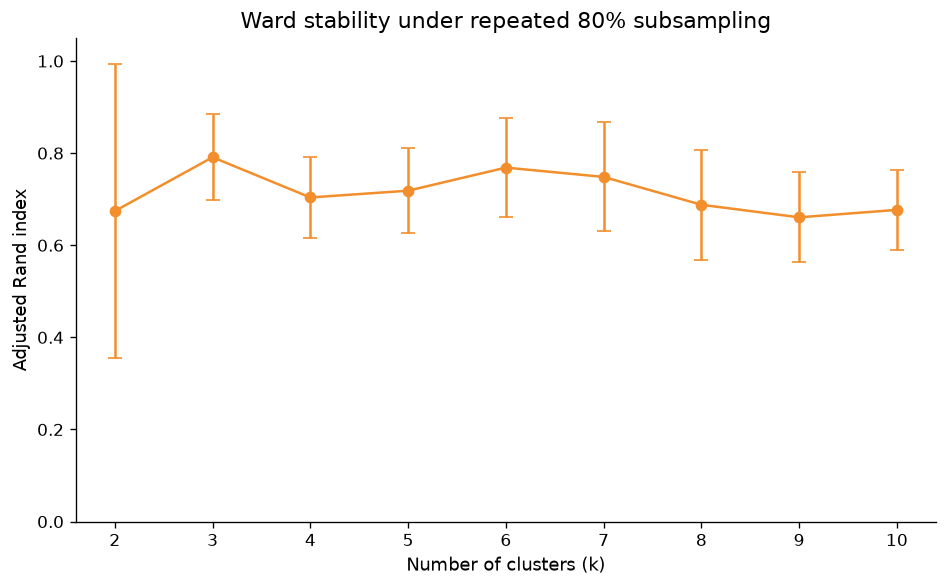

In [16]:
# Ward hierarchical-clustering stability under repeated subsampling.

WARD_STABILITY_REPETITIONS = 100
WARD_SUBSAMPLE_FRACTION = 0.80

ward_stability_rng = np.random.default_rng(
    RANDOM_STATE + 10_000
)

subsample_size = round(
    WARD_SUBSAMPLE_FRACTION * len(retained_scores)
)

# Generate the subsets once so every value of k is evaluated
# using exactly the same observations.
ward_subsamples = [
    np.sort(
        ward_stability_rng.choice(
            len(retained_scores),
            size=subsample_size,
            replace=False,
        )
    )
    for _ in range(WARD_STABILITY_REPETITIONS)
]

ward_stability_rows = []

for k in k_values:
    full_ward_labels = hierarchical_labels[k]
    ari_values = []

    for indices in ward_subsamples:
        subsample_linkage = linkage(
            retained_scores[indices],
            method="ward",
            metric="euclidean",
        )

        subsample_labels = fcluster(
            subsample_linkage,
            t=k,
            criterion="maxclust",
        )

        # Compare the subsample solution with the full-data Ward
        # solution restricted to the same observations.
        ari_values.append(
            adjusted_rand_score(
                full_ward_labels[indices],
                subsample_labels,
            )
        )

    ward_stability_rows.append({
        "k": k,
        "Mean subsample ARI": np.mean(ari_values),
        "SD": np.std(ari_values, ddof=1),
        "5th percentile": np.quantile(ari_values, 0.05),
        "Median": np.median(ari_values),
        "95th percentile": np.quantile(ari_values, 0.95),
    })

ward_stability = (
    pd.DataFrame(ward_stability_rows)
    .set_index("k")
)

display(ward_stability.round(4))

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    ward_stability.index,
    ward_stability["Mean subsample ARI"],
    yerr=ward_stability["SD"],
    marker="o",
    capsize=4,
    color="#F28E2B",
)

ax.set_ylim(0, 1.05)
ax.set_xticks(list(k_values))
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Adjusted Rand index")
ax.set_title(
    "Ward stability under repeated 80% subsampling"
)

fig.tight_layout()
plt.show()

Error bars represent ±1 standard deviation across the 100 subsamples.

Ward hierarchical-clustering stability was evaluated by refitting the model on 100 random subsets containing 80% of the observations. Each subsample solution was compared with the full-data Ward partition restricted to the same wines using the adjusted Rand index. For $k=3$, the mean ARI was 0.791, with a median of 0.793 and a 5th-to-95th-percentile interval of 0.653 to 0.940. The three-cluster solution had the highest mean stability among the evaluated values of $k$, providing additional support for the three-group Ward partition. These results indicate moderately strong, although not perfect, stability under changes in sample composition. Because hierarchical merges are permanent, some variation across subsamples is expected; this analysis supports the reproducibility of the partition but does not establish that the dendrogram represents a uniquely correct taxonomy.

In [17]:
# Sensitivity to the linkage definition at a three-cluster cut.
linkage_rows = []
for method in ["single", "complete", "average", "ward"]:
    matrix = linkage(retained_scores, method=method, metric="euclidean")
    labels = fcluster(matrix, t=3, criterion="maxclust")
    coph, _ = cophenet(matrix, pdist(retained_scores))
    linkage_rows.append({
        "Linkage": method.title(),
        "Cophenetic correlation": coph,
        "Three-cluster silhouette": silhouette_score(retained_scores, labels),
        "Smallest cluster": np.bincount(labels)[1:].min(),
        "Largest cluster": np.bincount(labels)[1:].max(),
    })

linkage_sensitivity = pd.DataFrame(linkage_rows).set_index("Linkage")
display(linkage_sensitivity.round(4))

,Cophenetic correlation,Three-cluster silhouette,Smallest cluster,Largest cluster
Linkage,,,,
Single,0.5309,0.1069,1,176
Complete,0.5433,0.2276,23,107
Average,0.7691,0.3177,1,127
Ward,0.6911,0.3468,55,65


In [18]:
from scipy.optimize import linear_sum_assignment

ward_raw = hierarchical_labels[3]

# Find the globally optimal Ward-to-k-means label alignment by
# maximizing the total number of matching observations.
cross_raw = pd.crosstab(kmeans_cluster, ward_raw)

row_indices, column_indices = linear_sum_assignment(
    -cross_raw.to_numpy()
)

ward_map = {
    cross_raw.columns[column_index]: cross_raw.index[row_index]
    for row_index, column_index in zip(row_indices, column_indices)
}

# Confirm that every Ward label received a corresponding k-means label.
if set(ward_map) != set(np.unique(ward_raw)):
    raise ValueError("Not all Ward labels were aligned.")

ward_cluster = pd.Series(
    [ward_map[label] for label in ward_raw],
    index=wine.index,
    name="Ward cluster",
)

agreement = adjusted_rand_score(
    kmeans_cluster,
    ward_cluster,
)

comparison = pd.crosstab(
    kmeans_cluster,
    ward_cluster,
)

comparison.index.name = "K-means cluster"
comparison.columns.name = "Ward cluster"

exact_agreement = (
    kmeans_cluster.to_numpy()
    == ward_cluster.to_numpy()
).mean()

display(comparison)

print(
    "Adjusted Rand index between k-means and Ward solutions: "
    f"{agreement:.3f}"
)
print(
    "Exact agreement after globally optimal label alignment: "
    f"{exact_agreement:.1%}"
)

Ward cluster,1,2,3
K-means cluster,,,
1,49,2,0
2,6,56,3
3,0,0,62


Adjusted Rand index between k-means and Ward solutions: 0.827
Exact agreement after globally optimal label alignment: 93.8%


### Hierarchical-clustering findings

The three-group Ward solution has a silhouette coefficient of approximately 0.347, which is the strongest Ward result among $k=2$ through $k=10$.  Its cophenetic correlation is approximately 0.691, indicating that the dendrogram preserves the original five-dimensional distances moderately well, but not perfectly.

The adjusted Rand index between the three-cluster Ward and k-means solutions is approximately 0.827, with 93.8% exact agreement after the arbitrary labels are aligned.  The strong agreement is notable because the algorithms build groups differently:  k-means directly minimizes within-cluster squared distance, whereas hierarchical clustering makes a permanent sequence of merges.  Their convergence on similar structure strengthens the evidence for three broad chemical profiles.

The linkage sensitivity table also demonstrates that hierarchical results depend on the definition of distance between groups.  Average linkage preserves pairwise distances better than Ward in this dataset, but Ward produces the strongest three-cluster silhouette and aligns with the compact-group objective used by k-means.  Single linkage yields a highly imbalanced result, consistent with its tendency to form chains.

## Sensitivity to the PCA Variance-Retention Threshold

In [19]:
# Sensitivity to the PCA variance-retention threshold

from IPython.display import Markdown, display

PCA_SENSITIVITY_THRESHOLDS = [0.75, 0.80, 0.85, 0.90]
K_VALUES = range(2, 11)

# Primary partitions from the required 80%-retention analysis.
primary_kmeans_labels = kmeans_final.labels_
primary_ward_labels = hierarchical_labels[3]

pca_sensitivity_rows = []

for threshold in PCA_SENSITIVITY_THRESHOLDS:
    n_components = int(np.searchsorted(cumulative, threshold) + 1)
    threshold_scores = all_scores[:, :n_components]
    retained_variance = cumulative[n_components - 1]

    # Evaluate alternative values of k at this PCA threshold.
    silhouette_by_k = {}

    for k in K_VALUES:
        model = KMeans(
            n_clusters=k,
            n_init=50,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(threshold_scores)
        silhouette_by_k[k] = silhouette_score(
            threshold_scores,
            labels,
        )

    best_k = max(silhouette_by_k, key=silhouette_by_k.get)

    # Obtain the k=3 k-means solution.
    kmeans_three = KMeans(
        n_clusters=3,
        n_init=50,
        random_state=RANDOM_STATE,
    ).fit_predict(threshold_scores)

    # Obtain the k=3 Ward hierarchical solution.
    ward_matrix = linkage(
        threshold_scores,
        method="ward",
        metric="euclidean",
    )
    ward_three = fcluster(
        ward_matrix,
        t=3,
        criterion="maxclust",
    )

    pca_sensitivity_rows.append({
        "Target variance (%)": threshold * 100,
        "Components retained": n_components,
        "Actual variance (%)": retained_variance * 100,
        "Best k by silhouette": best_k,
        "Best silhouette": silhouette_by_k[best_k],
        "k=3 silhouette": silhouette_by_k[3],
        "K-means ARI vs. primary": adjusted_rand_score(
            primary_kmeans_labels,
            kmeans_three,
        ),
        "Ward silhouette (k=3)": silhouette_score(
            threshold_scores,
            ward_three,
        ),
        "Ward ARI vs. primary": adjusted_rand_score(
            primary_ward_labels,
            ward_three,
        ),
        "K-means/Ward ARI": adjusted_rand_score(
            kmeans_three,
            ward_three,
        ),
    })

pca_sensitivity = (
    pd.DataFrame(pca_sensitivity_rows)
    .set_index("Target variance (%)")
)

retention_summary = pca_sensitivity[
    [
        "Components retained",
        "Actual variance (%)",
        "Best k by silhouette",
        "Best silhouette",
        "k=3 silhouette",
    ]
]

agreement_summary = pca_sensitivity[
    [
        "K-means ARI vs. primary",
        "Ward silhouette (k=3)",
        "Ward ARI vs. primary",
        "K-means/Ward ARI",
    ]
]

display(Markdown("**PCA retention and cluster-selection results**"))
display(
    retention_summary.round({
        "Actual variance (%)": 2,
        "Best silhouette": 3,
        "k=3 silhouette": 3,
    })
)

display(Markdown("**Partition agreement and Ward results**"))
display(
    agreement_summary.round({
        "K-means ARI vs. primary": 3,
        "Ward silhouette (k=3)": 3,
        "Ward ARI vs. primary": 3,
        "K-means/Ward ARI": 3,
    })
)

**PCA retention and cluster-selection results**

,Components retained,Actual variance (%),Best k by silhouette,Best silhouette,k=3 silhouette
Target variance (%),,,,,
75.0,5,80.16,3,0.369,0.369
80.0,5,80.16,3,0.369,0.369
85.0,6,85.10,3,0.346,0.346
90.0,8,92.02,3,0.315,0.315


**Partition agreement and Ward results**

,K-means ARI vs. primary,Ward silhouette (k=3),Ward ARI vs. primary,K-means/Ward ARI
Target variance (%),,,,
75.0,1.0,0.347,1.000,0.827
80.0,1.0,0.347,1.000,0.827
85.0,1.0,0.337,0.846,0.915
90.0,1.0,0.305,0.919,0.837


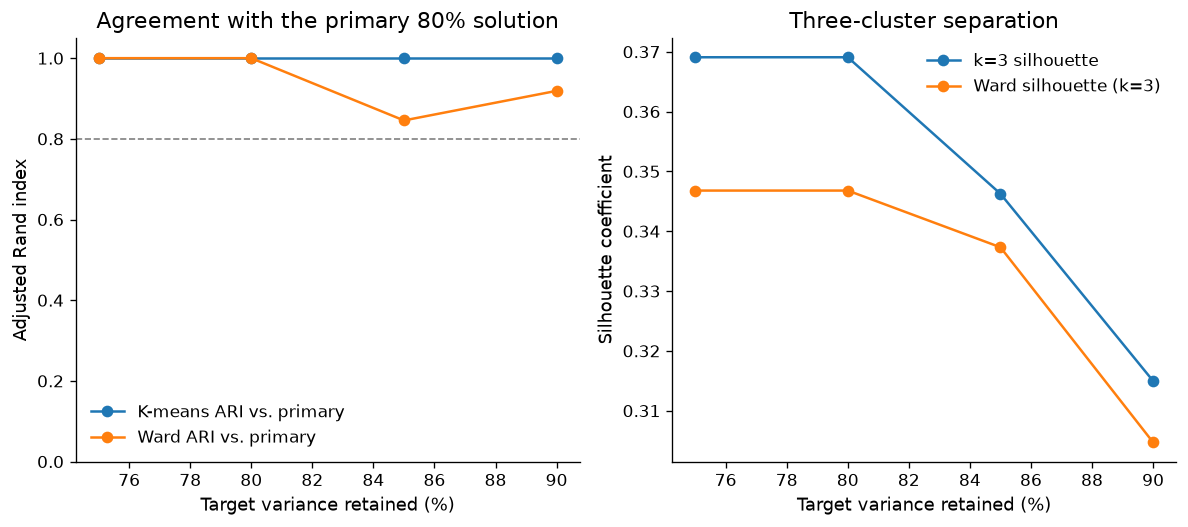

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

pca_sensitivity[
    ["K-means ARI vs. primary", "Ward ARI vs. primary"]
].plot(
    marker="o",
    ylim=(0, 1.05),
    ax=axes[0],
)
axes[0].axhline(
    0.80,
    color="gray",
    linestyle="--",
    linewidth=1,
)
axes[0].set_title("Agreement with the primary 80% solution")
axes[0].set_xlabel("Target variance retained (%)")
axes[0].set_ylabel("Adjusted Rand index")
axes[0].legend(frameon=False)

pca_sensitivity[
    ["k=3 silhouette", "Ward silhouette (k=3)"]
].plot(
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Three-cluster separation")
axes[1].set_xlabel("Target variance retained (%)")
axes[1].set_ylabel("Silhouette coefficient")
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

The PCA-retention sensitivity analysis evaluated target thresholds of 75%, 80%, 85%, and 90%. Because four components did not reach 75%, both the 75% and 80% targets retained the same five components and explained 80.16% of standardized variance. The 85% target retained six components and explained 85.10%, while the 90% target retained eight components and explained 92.02%. The silhouette criterion selected $k=3$ at every threshold.  Moreover, the three-cluster k-means partition was identical to the primary solution at all four thresholds, with an adjusted Rand index of 1.000 in every comparison. The Ward solution was also unchanged at the 75% and 80% thresholds and remained strongly similar at 85% and 90%, with adjusted Rand indices of 0.846 and 0.919, respectively. Agreement between the corresponding k-means and Ward solutions ranged from 0.827 to 0.915. Cluster separation decreased modestly as additional components were retained: the k-means silhouette coefficient declined from 0.369 with five components to 0.346 with six and 0.315 with eight, while the Ward silhouette declined from 0.347 to 0.337 and 0.305. Collectively, these results show that the preferred three-group structure is not materially dependent on the exact PCA-retention threshold. The required 80% solution remains appropriate because it preserves the same substantive partition while providing slightly clearer separation and a more parsimonious representation than the higher-threshold alternatives.

## Outlier-sensitivity analysis

In [21]:
# Outlier-sensitivity analysis:
# Winsorize each variable at its previously calculated 1.5-IQR fences.

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

wine_winsorized = wine.clip(
    lower=lower_fence,
    upper=upper_fence,
    axis="columns",
)

# Re-standardize after winsorization.
X_winsorized = (
    (wine_winsorized - wine_winsorized.mean())
    / wine_winsorized.std(ddof=1)
)

# Repeat PCA and apply the same 80% retention rule.
pca_winsorized = PCA(svd_solver="full")
all_scores_winsorized = pca_winsorized.fit_transform(X_winsorized)

explained_winsorized = pca_winsorized.explained_variance_ratio_
cumulative_winsorized = np.cumsum(explained_winsorized)
n_components_winsorized = int(
    np.searchsorted(cumulative_winsorized, 0.80) + 1
)

scores_winsorized = all_scores_winsorized[
    :, :n_components_winsorized
]

print(
    "Winsorized PCA retention: "
    f"{n_components_winsorized} components explain "
    f"{cumulative_winsorized[n_components_winsorized - 1]:.2%}."
)

# Re-evaluate k-means across the original candidate range.
winsorized_kmeans_rows = []
winsorized_kmeans_models = {}

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=50,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(scores_winsorized)
    winsorized_kmeans_models[k] = model

    winsorized_kmeans_rows.append({
        "k": k,
        **clustering_metrics(
            scores_winsorized,
            labels,
            model.inertia_,
        ),
    })

winsorized_kmeans_results = (
    pd.DataFrame(winsorized_kmeans_rows)
    .set_index("k")
)

display(winsorized_kmeans_results.round(4))

# Compare the original and winsorized k=3 assignments.
winsorized_kmeans_labels = winsorized_kmeans_models[3].labels_

kmeans_outlier_ari = adjusted_rand_score(
    kmeans_cluster,
    winsorized_kmeans_labels,
)

# Repeat Ward clustering and compare assignments.
winsorized_linkage = linkage(
    scores_winsorized,
    method="ward",
    metric="euclidean",
)

winsorized_ward_labels = fcluster(
    winsorized_linkage,
    t=3,
    criterion="maxclust",
)

ward_outlier_ari = adjusted_rand_score(
    ward_raw,
    winsorized_ward_labels,
)

sensitivity_summary = pd.DataFrame({
    "Diagnostic": [
        "Original PCA components retained",
        "Winsorized PCA components retained",
        "Original variance retained",
        "Winsorized variance retained",
        "K-means assignment ARI",
        "Ward assignment ARI",
    ],
    "Result": [
        n_components_80,
        n_components_winsorized,
        cumulative[n_components_80 - 1],
        cumulative_winsorized[n_components_winsorized - 1],
        kmeans_outlier_ari,
        ward_outlier_ari,
    ],
})

display(sensitivity_summary.round(4))

Winsorized PCA retention: 5 components explain 80.36%.


,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Smallest cluster,Largest cluster
k,,,,,,
2,1194.8621,0.3344,96.3519,1.2047,65,113
3,812.8225,0.3680,111.5435,1.0884,51,65
4,714.2445,0.3189,92.1470,1.4114,33,52
5,644.4937,0.3079,80.8303,1.2929,24,51
6,589.1988,0.2727,73.5524,1.2819,13,47
7,543.8676,0.2392,68.3919,1.4025,16,40
8,512.0919,0.2235,63.4020,1.3847,4,35
9,481.9087,0.2234,59.9277,1.3222,12,33
10,454.9833,0.2236,57.1923,1.2832,4,36


,Diagnostic,Result
0,Original PCA components retained,5.0000
1,Winsorized PCA components retained,5.0000
2,Original variance retained,0.8016
3,Winsorized variance retained,0.8036
4,K-means assignment ARI,1.0000
5,Ward assignment ARI,0.8116


The IQR screening identified 21 flagged values across 17 wines, but such flags do not establish measurement errors.  To evaluate their influence, the analysis was repeated after winsorizing each variable at its 1.5-IQR fences and re-standardizing the data.  The winsorized analysis retained five principal components explaining 80.36% of standardized variance.  The silhouette, Calinski–Harabasz, and Davies–Bouldin indices continued to favor k = 3.  Agreement between the original and winsorized three-cluster solutions was perfect for k-means (adjusted Rand index = 1.000) and strong for Ward clustering (adjusted Rand index = 0.812).  Thus, reducing the influence of flagged observations did not materially alter the principal conclusions, although Ward assignments were somewhat more sensitive than k-means assignments.

## 7. Consolidated assumptions and limitations

| Issue | Evidence from this analysis | Consequence |
|---|---|---|
| Numeric inputs and comparable scale | All 13 variables are numeric; standardized means are approximately zero and sample standard deviations equal one. | Standardization prevents large-unit variables such as `Proline` from dominating distances. |
| Correlated structure for PCA | Bartlett's test is highly significant; KMO is about 0.779; several correlations are large. | PCA has meaningful shared linear structure to summarize. |
| Linearity | PCA captures linear combinations only. | Nonlinear relationships may not be represented efficiently. |
| Independence | Rows are assumed to represent separate wines; the sampling design cannot be verified from the CSV. | Unmodeled batch or producer dependence could exaggerate apparent structure. |
| Outliers | The IQR rule flagged 21 cells in 17 rows. After winsorization, five PCs retained 80.36%; k-means ARI was 1.000 and Ward ARI was 0.812 relative to the original solutions. | The PCA retention and three-cluster conclusions are robust to reduced outlier influence, although Ward membership is somewhat more sensitive than k-means membership. |
| Euclidean, compact-cluster geometry | K-means and Ward both use squared Euclidean variation in the retained component space. | Curved, highly unequal-density, or strongly non-spherical groups may be summarized poorly. |
| Choice of $k$ | Three internal indices and subsampling stability favor $k=3$; silhouette separation is moderate rather than strong. | Three clusters are defensible, but not uniquely proven. |
| PCA retention threshold | Five components retain 80.16% of standardized variance. Sensitivity analyses retained five, six, and eight components at the evaluated thresholds. The silhouette criterion selected $k=3$ throughout; all k-means partitions were identical to the primary solution (ARI = 1.000), and Ward agreement with the primary solution ranged from 0.846 to 1.000. However, the k-means silhouette declined from 0.369 to 0.315 as additional components were retained. | The three-cluster conclusion is robust to the evaluated PCA-retention thresholds. Retaining additional components does not change the k-means partition and only modestly changes the Ward partition, while slightly weakening cluster separation; therefore, the five-component 80% solution is both defensible and parsimonious. |
| Hierarchical linkage | Ward, average, complete, and single linkage produce different diagnostics. | The dendrogram is method-dependent; it should not be treated as a uniquely correct taxonomy. |
| External validity | No target, cultivar, origin, or quality label appears in the file. | Internal metrics evaluate compactness and separation, not substantive correctness or predictive accuracy. |
| Cluster tendency | Across 200 repetitions, the Hopkins statistic averaged 0.7235, with a 5th–95th percentile interval of 0.6815–0.7611. | The retained PCA space shows meaningful nonrandom clustering tendency, supporting exploratory clustering but not proving a uniquely correct partition. |
| Hierarchical stability | Across 100 repeated 80% subsamples, the three-group Ward solution had the highest mean ARI, 0.791, with a 5th–95th percentile interval of 0.653–0.940. | The three-group Ward partition shows moderately strong reproducibility under changes in sample composition, although individual assignments remain sample-dependent. |

Jain (2010) cautions that clustering validity depends on the data representation, distance measure, and algorithm.  The diagnostics above therefore support a reasoned interpretation, not a claim that the groups are objectively true classes.

## 8. Overall interpretation and conclusion

Standardization and PCA reduced 13 correlated chemical measurements to five orthogonal components while retaining 80.16% of total variance.  The leading component is a phenolic-composition dimension, while the second emphasizes color intensity, alcohol, and proline.  These findings show that much of the original information can be represented with substantially fewer dimensions, consistent with the information-preserving purpose of PCA described by Jolliffe and Cadima (2016).

Across $k=2$ through $k=10$, k-means with three clusters provides the strongest combined internal validation and the highest subsampling stability. The groups correspond to: (1) a lower-phenolic, higher-color-intensity profile; (2) a lower-alcohol, lower-color, lower-proline profile; and (3) a higher-phenolic, higher-proline profile. Ward hierarchical clustering independently recovers a similar three-group structure, with an adjusted Rand index of approximately 0.827 relative to k-means. The three-cluster conclusion was also robust across PCA-retention targets from 75% through 90%: the k-means partition remained identical to the primary solution, while the Ward partitions remained strongly similar.

The practical value of the analysis is exploratory. As Tufariello et al. (2022) illustrate in wine chemometrics, PCA and hierarchical clustering can reveal multivariate chemical patterns that are not apparent when measurements are considered separately. In this analysis, winsorization produced the same five-component PCA retention decision and an identical k-means partition, while the Ward solution remained strongly similar. Repeated subsampling further showed that the three-group Ward partition had the highest mean stability among the evaluated alternatives, with a mean adjusted Rand index of 0.791.  These results indicate that the principal findings are robust to reduced outlier influence, although Ward assignments show some sensitivity. Nevertheless, the moderate silhouette coefficient and absence of external labels preclude stronger claims about cultivar, quality, authenticity, or geographic origin. A future confirmatory study would require independently collected wines and verified outcome labels.


<div style="text-align:center; font-weight:bold; font-size:1.15em; margin-top:1em;">References</div>

<div style="margin-left:0.5in; text-indent:-0.5in; line-height:2; margin-top:1em;">
Aeberhard, S., &amp; Forina, M. (1992). <em>Wine</em> [Data set]. UCI Machine Learning Repository. <a href="https://doi.org/10.24432/C5PC7J" target="_blank" rel="noopener noreferrer">https://doi.org/10.24432/C5PC7J</a>
</div>

<div style="margin-left:0.5in; text-indent:-0.5in; line-height:2;">
Hopkins, B., &amp; Skellam, J. G. (1954). A new method for determining the type of distribution of plant individuals. <em>Annals of Botany, 18</em>(2), 213–227. <a href="https://doi.org/10.1093/oxfordjournals.aob.a083391" target="_blank" rel="noopener noreferrer">https://doi.org/10.1093/oxfordjournals.aob.a083391</a>
</div>

<div style="margin-left:0.5in; text-indent:-0.5in; line-height:2;">
Jain, A. K. (2010). Data clustering: 50 years beyond K-means. <em>Pattern Recognition Letters, 31</em>(8), 651–666. <a href="https://doi.org/10.1016/j.patrec.2009.09.011" target="_blank" rel="noopener noreferrer">https://doi.org/10.1016/j.patrec.2009.09.011</a>
</div>

<div style="margin-left:0.5in; text-indent:-0.5in; line-height:2;">
Jolliffe, I. T., &amp; Cadima, J. (2016). Principal component analysis: A review and recent developments. <em>Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 374</em>(2065), 20150202. <a href="https://doi.org/10.1098/rsta.2015.0202" target="_blank" rel="noopener noreferrer">https://doi.org/10.1098/rsta.2015.0202</a>
</div>

<div style="margin-left:0.5in; text-indent:-0.5in; line-height:2;">
Tufariello, M., Pati, S., Palombi, L., Grieco, F., &amp; Losito, I. (2022). Use of multivariate statistics in the processing of data on wine volatile compounds obtained by HS-SPME-GC-MS. <em>Foods, 11</em>(7), Article 910. <a href="https://doi.org/10.3390/foods11070910" target="_blank" rel="noopener noreferrer">https://doi.org/10.3390/foods11070910</a>
</div>
